# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402137
- 姓名：排黒尔丁·罗合曼
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-pahir219
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于福州11856条二手房房源数据，从区域分布、价格特征、户型结构、房龄影响等多个维度进行系统性分析。使用Pandas进行数据清洗与统计分析，结合Matplotlib和Seaborn绘制可视化图表，揭示福州二手房市场的核心特征。主要结论包括：鼓楼区均价最高（约2.5万元/㎡），晋安和仓山为房源主力供应区（合计占比约70%）；3室户型占比超60%，为市场主流；房龄与价格呈负相关，新房溢价明显；总价集中在130-225万区间，均价中位数约1.8万元/㎡。

## 2. 数据读取与分析目标

### 数据来源
本次分析数据来源于安居客平台福州二手房房源信息，共包含11856条有效记录。

### 字段说明
- **市区**：房源所在行政区
- **户型**：房屋户型（室/厅/卫）
- **面积数值**：房屋建筑面积（㎡）
- **方位**：房屋朝向
- **楼层**：楼层位置（低/中/高层）
- **总价数值**：房屋总价（万元）
- **均价数值**：房屋单价（元/㎡）
- **房龄**：房屋建成年代分类

### 分析目标
1. 各区域房源数量与价格分布对比
2. 户型结构与价格关系分析
3. 房龄对房价的影响
4. 面积与总价的相关性
5. 楼层、朝向等因素对价格的影响

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

In [2]:
# 读取数据
df = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')
print('数据形状:', df.shape)
df.head()

数据形状: (11856, 18)


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据清洗与预处理

In [3]:
# 检查缺失值
print('缺失值统计：')
print(df.isnull().sum())

# 删除价格缺失的记录
df = df.dropna(subset=['总价数值', '均价数值'])
print('\n删除缺失值后数据形状:', df.shape)

缺失值统计：
id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64

删除缺失值后数据形状: (11830, 18)


In [4]:
# 提取室数（用于户型分析）
df['室数'] = df['户型'].str.extract(r'(\d+)\s*室').astype(float)

# 提取楼层类型
df['楼层类型'] = df['楼层'].str.extract(r'(.+?)\(')

# 数据概览
df[['面积数值', '总价数值', '均价数值']].describe()

,面积数值,总价数值,均价数值
count,11830.000000,11830.000000,11830.00000
mean,97.843371,190.761657,19235.60093
std,25.897159,111.174039,6925.94972
min,18.000000,16.800000,2169.00000
25%,84.562500,130.000000,15298.25000
50%,93.000000,173.000000,18325.50000
75%,113.000000,225.000000,22268.50000
max,500.000000,3180.000000,92968.00000


## 4. 探索性数据分析与可视化

### 4.1 区域分布分析

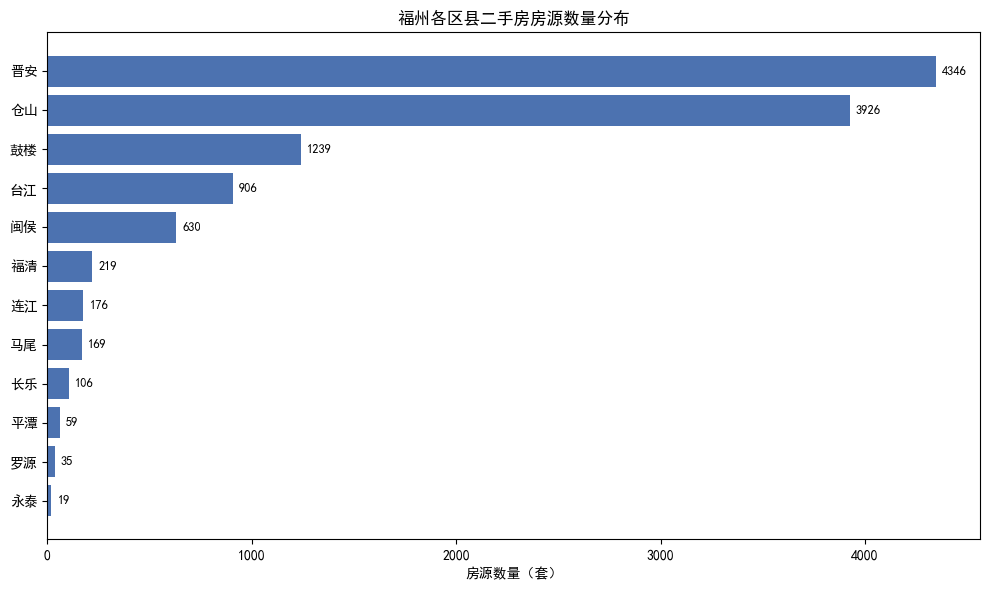

In [5]:
# 各区域房源数量
district_count = df['市区'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(district_count.index, district_count.values, color='#4C72B0')
ax.set_xlabel('房源数量（套）')
ax.set_title('福州各区县二手房房源数量分布')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 30, bar.get_y() + bar.get_height()/2, f'{int(width)}', 
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

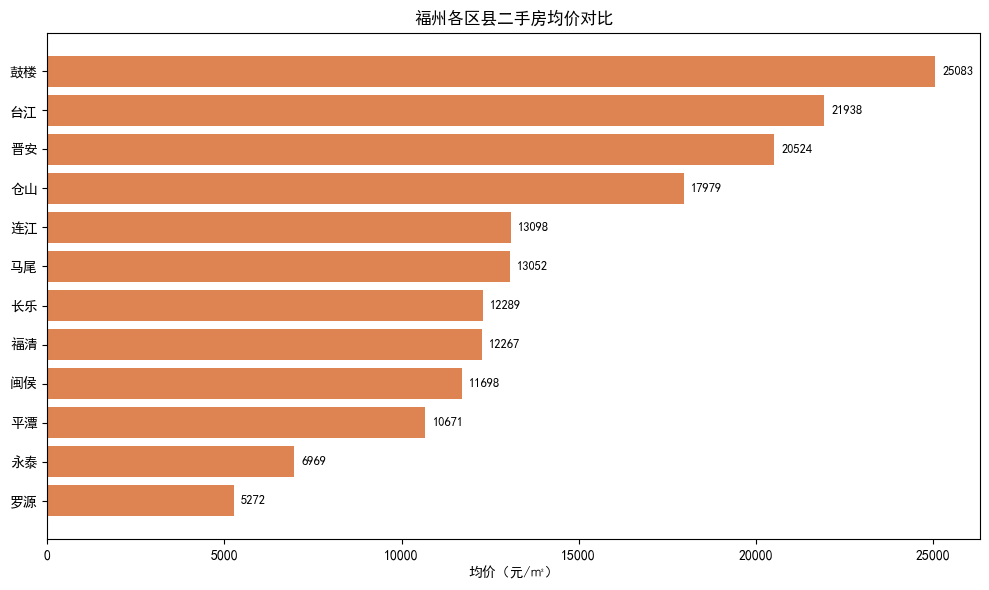

In [6]:
# 各区域均价对比
district_price = df.groupby('市区')['均价数值'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(district_price.index, district_price.values, color='#DD8452')
ax.set_xlabel('均价（元/㎡）')
ax.set_title('福州各区县二手房均价对比')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height()/2, f'{int(width)}', 
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

核心城区均价显著领跑，呈现清晰的中心 - 外围梯度。
- 鼓楼区以 25083 元 /㎡位居全市第一，台江、晋安紧随其后均突破 2 万元 /㎡，仓山接近 1.8 万元 /㎡；
- 远郊县域均价大幅回落，罗源、永泰不足万元，最低的罗源仅 5272 元 /㎡，首尾价差接近 5 倍，区域分化十分明显。

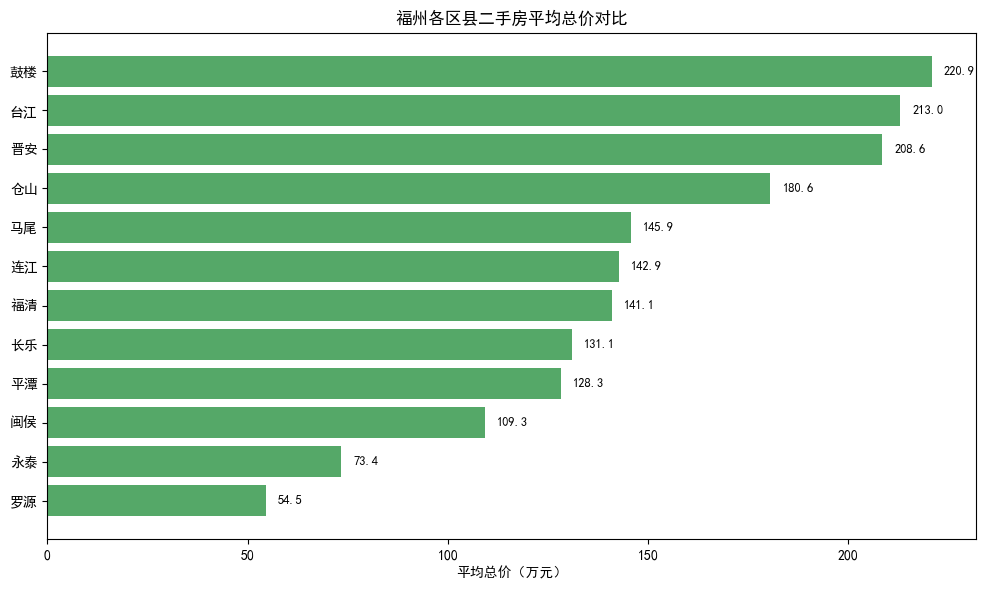

In [7]:
# 各区域总价对比
district_total = df.groupby('市区')['总价数值'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(district_total.index, district_total.values, color='#55A868')
ax.set_xlabel('平均总价（万元）')
ax.set_title('福州各区县二手房平均总价对比')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 3, bar.get_y() + bar.get_height()/2, f'{width:.1f}', 
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

总价排名与均价高度一致，购房成本的区域差异同样悬殊。
- 鼓楼、台江、晋安单套平均总价均突破 200 万元，鼓楼最高达 220.9 万元；
- 郊县中闽侯、永泰、罗源总价门槛较低，罗源仅 54.5 万元，核心城区的购房资金门槛约为远郊的 4 倍。

### 4.2 价格分布分析

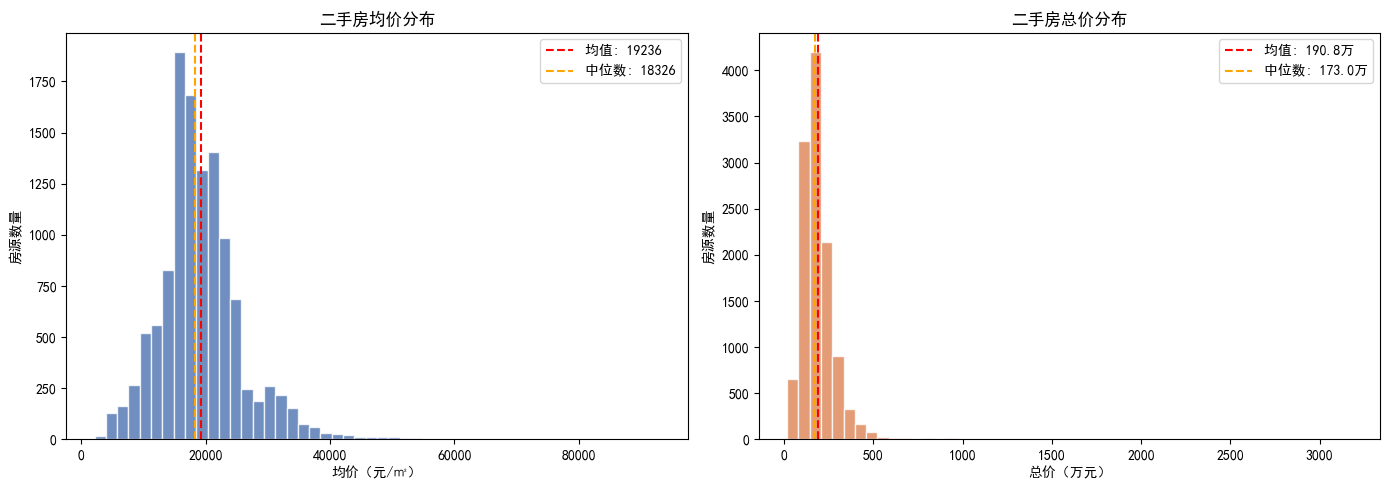

In [8]:
# 均价分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 均价分布
axes[0].hist(df['均价数值'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(df['均价数值'].mean(), color='red', linestyle='--', label=f'均值: {df["均价数值"].mean():.0f}')
axes[0].axvline(df['均价数值'].median(), color='orange', linestyle='--', label=f'中位数: {df["均价数值"].median():.0f}')
axes[0].set_xlabel('均价（元/㎡）')
axes[0].set_ylabel('房源数量')
axes[0].set_title('二手房均价分布')
axes[0].legend()

# 总价分布
axes[1].hist(df['总价数值'], bins=50, color='#DD8452', edgecolor='white', alpha=0.8)
axes[1].axvline(df['总价数值'].mean(), color='red', linestyle='--', label=f'均值: {df["总价数值"].mean():.1f}万')
axes[1].axvline(df['总价数值'].median(), color='orange', linestyle='--', label=f'中位数: {df["总价数值"].median():.1f}万')
axes[1].set_xlabel('总价（万元）')
axes[1].set_ylabel('房源数量')
axes[1].set_title('二手房总价分布')
axes[1].legend()

plt.tight_layout()
plt.show()

 全市房价呈典型的右偏分布：
- 均价均值 19236 元 /㎡、中位数 18326 元 /㎡，峰值集中在 1.5-2 万元 /㎡区间，少量高价房源拉高了整体均值。
- 总价均值 190.8 万元、中位数 173.0 万元，绝大多数房源总价在 500 万元以内，100-200 万元是市场绝对主力价位段。

### 4.3 户型分析

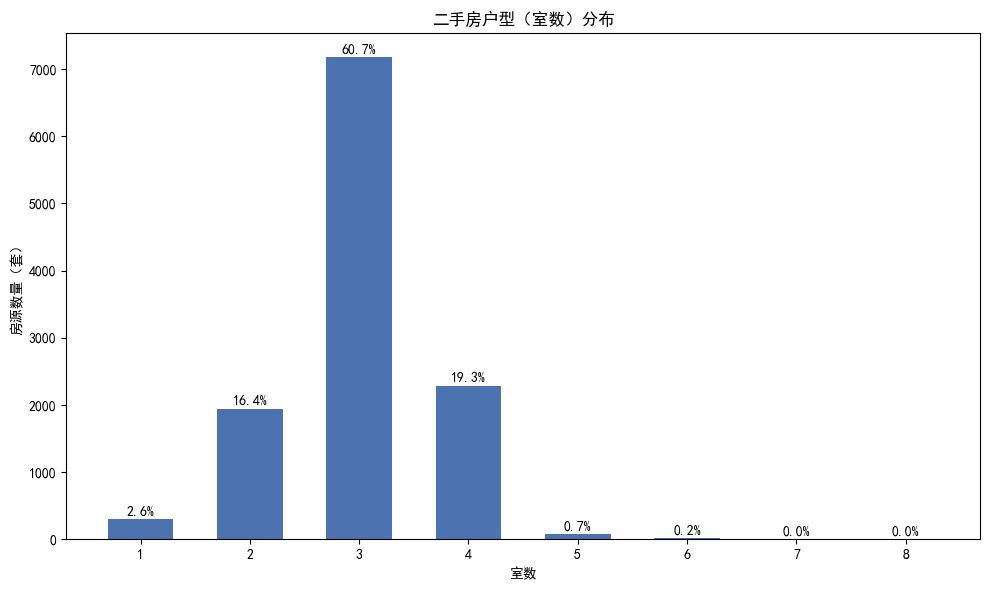

In [9]:
# 室数分布
room_count = df['室数'].value_counts().sort_index()
room_pct = room_count / room_count.sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(room_count.index.astype(int).astype(str), room_count.values, color='#4C72B0', width=0.6)
ax.set_xlabel('室数')
ax.set_ylabel('房源数量（套）')
ax.set_title('二手房户型（室数）分布')
for bar, pct in zip(bars, room_pct.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 50, f'{pct:.1f}%', 
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()

- 三居室是市场绝对主流，占比达 60.7%；其次是四居室（19.3%）和两居室（16.4%）；
- 一居室及五室以上大户型占比极低，合计不足 4%。反映出福州二手房市场以刚需 + 刚改需求为主，三居室是供需最集中的户型品类。

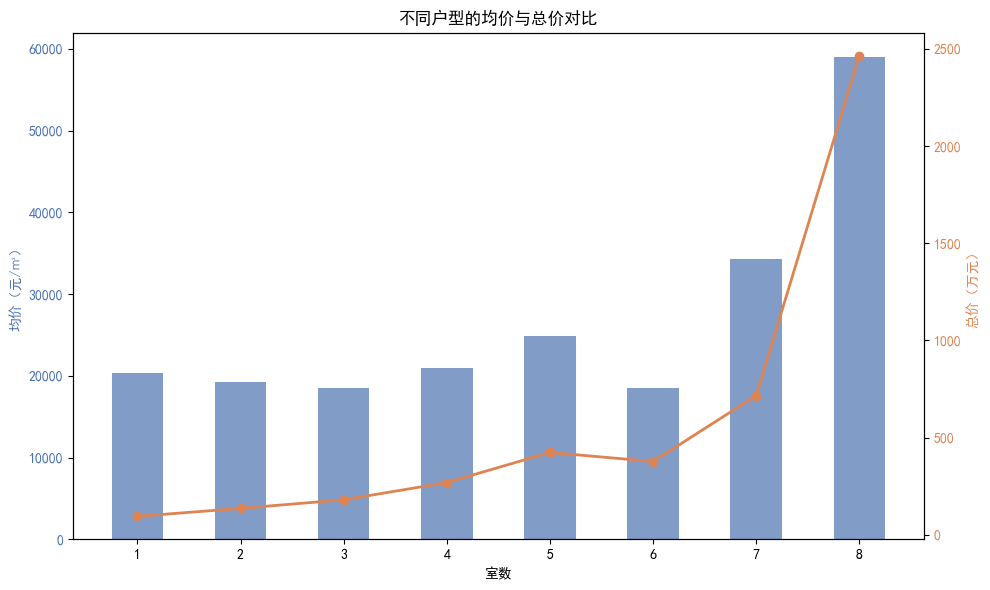

In [10]:
# 不同户型的均价和总价对比
room_price = df.groupby('室数').agg({'均价数值': 'mean', '总价数值': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

x = room_price['室数'].astype(int).astype(str)
ax1.bar(x, room_price['均价数值'], color='#4C72B0', alpha=0.7, label='均价', width=0.5)
ax1.set_xlabel('室数')
ax1.set_ylabel('均价（元/㎡）', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(x, room_price['总价数值'], color='#DD8452', marker='o', linewidth=2, label='总价')
ax2.set_ylabel('总价（万元）', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')

plt.title('不同户型的均价与总价对比')
fig.tight_layout()
plt.show()

- 1-6 室的普通住宅单价差异很小，基本维持在 2 万元 /㎡上下，说明中小户型的单价主要由地段决定，室数影响微弱；
- 总价随室数增加稳步上升。7 室及以上大户型（多为别墅、大平层）单价和总价同步大幅跳涨，属于高端改善品类，价格脱离普通住宅区间。

### 4.4 房龄与价格关系

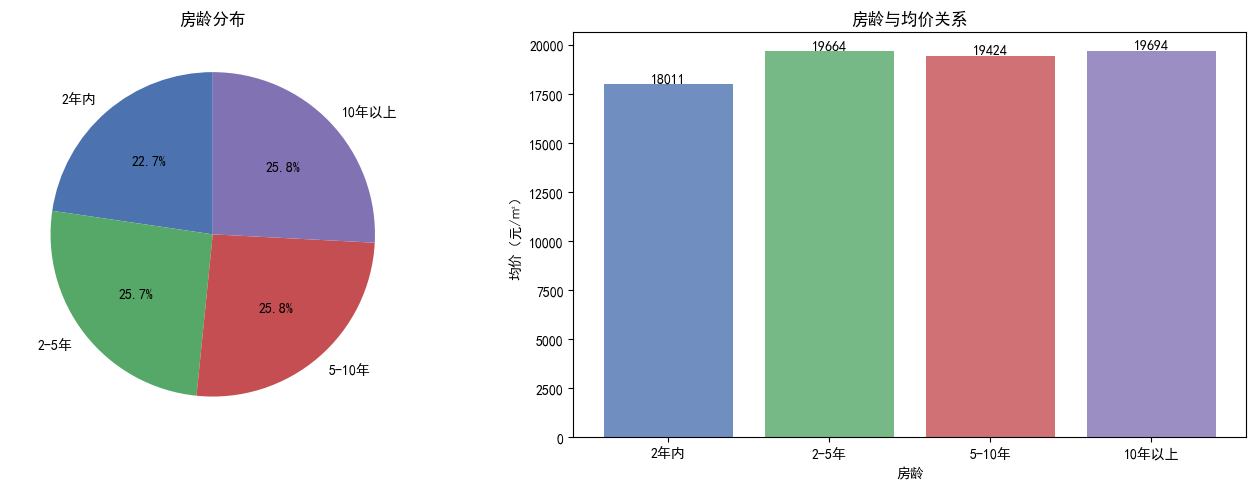

In [11]:
# 房龄排序
age_order = ['2年内', '2-5年', '5-10年', '10年以上']
age_price = df.groupby('房龄')['均价数值'].mean().reindex(age_order)
age_count = df['房龄'].value_counts().reindex(age_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 房龄分布
axes[0].pie(age_count.values, labels=age_count.index, autopct='%1.1f%%', 
            colors=['#4C72B0', '#55A868', '#C44E52', '#8172B3'], startangle=90)
axes[0].set_title('房龄分布')

# 房龄与均价关系
bars = axes[1].bar(age_price.index, age_price.values, 
                   color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'], alpha=0.8)
axes[1].set_xlabel('房龄')
axes[1].set_ylabel('均价（元/㎡）')
axes[1].set_title('房龄与均价关系')
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 100, f'{int(height)}', 
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()

- 房源房龄分布相对均匀，2 年内、2-5 年、5-10 年、10 年以上四个区间占比均在 22%-26% 之间。
- 均价上并非房龄越新价格越高：2 年内新房均价最低（18011 元 /㎡），10 年以上老房均价反而最高（19694 元 /㎡）。
- 核心原因是老房源多集中在核心地段，地段价值覆盖了房龄折旧的影响。

### 4.5 面积与总价相关性

相关系数: 0.624


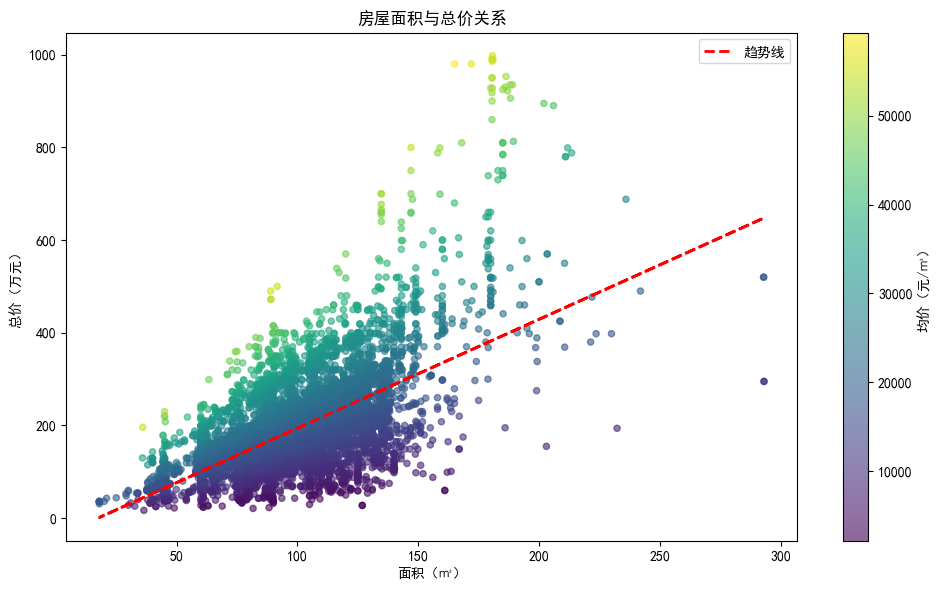

In [12]:
# 面积与总价散点图
fig, ax = plt.subplots(figsize=(10, 6))

# 过滤异常值便于观察
df_filtered = df[(df['面积数值'] < 300) & (df['总价数值'] < 1000)]

scatter = ax.scatter(df_filtered['面积数值'], df_filtered['总价数值'], 
                     c=df_filtered['均价数值'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='均价（元/㎡）')

# 添加趋势线
z = np.polyfit(df_filtered['面积数值'], df_filtered['总价数值'], 1)
p = np.poly1d(z)
ax.plot(df_filtered['面积数值'], p(df_filtered['面积数值']), 'r--', linewidth=2, label='趋势线')

ax.set_xlabel('面积（㎡）')
ax.set_ylabel('总价（万元）')
ax.set_title('房屋面积与总价关系')
ax.legend()

print(f'相关系数: {df_filtered["面积数值"].corr(df_filtered["总价数值"]):.3f}')
plt.tight_layout()
plt.show()

- 面积与总价呈显著的正相关关系，面积越大总价整体越高，符合基本市场规律；
- 同时散点颜色显示，大面积房源的单价普遍更高，说明大户型往往定位更高端、配套更好，呈现 “面积越大、单价越高、总价加速上涨” 的特征。
- 图中也存在少量异常值，为个别特殊房源。

### 4.6 楼层与朝向分析

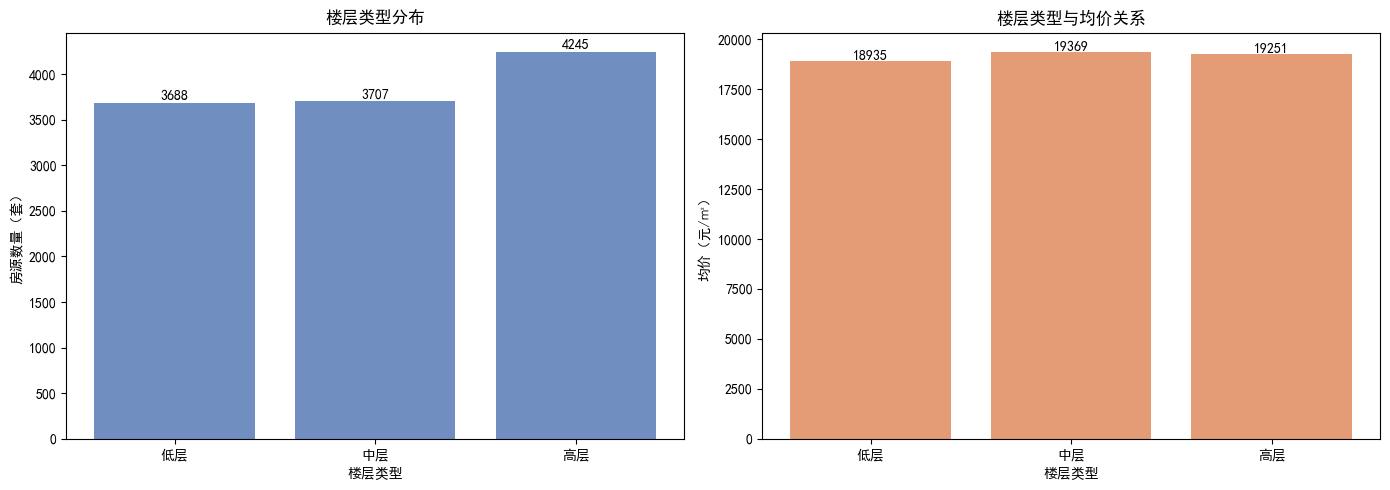

In [13]:
# 楼层类型均价对比
floor_order = ['低层', '中层', '高层']
floor_price = df.groupby('楼层类型')['均价数值'].mean().reindex(floor_order)
floor_count = df['楼层类型'].value_counts().reindex(floor_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(floor_count.index, floor_count.values, color='#4C72B0', alpha=0.8)
axes[0].set_xlabel('楼层类型')
axes[0].set_ylabel('房源数量（套）')
axes[0].set_title('楼层类型分布')
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 30, f'{int(height)}', 
                ha='center', fontsize=10)

bars2 = axes[1].bar(floor_price.index, floor_price.values, color='#DD8452', alpha=0.8)
axes[1].set_xlabel('楼层类型')
axes[1].set_ylabel('均价（元/㎡）')
axes[1].set_title('楼层类型与均价关系')
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 50, f'{int(height)}', 
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()

- 高层房源供给量最多（4245 套），低层、中层房源数量接近，三类楼层的供给整体均衡。
- 均价上三者差异极小：低层 18935 元 /㎡、中层 19369 元 /㎡、高层 19251 元 /㎡，价差不足千元。
- 说明在福州二手房市场中，楼层高低并非影响房屋定价的核心因素。

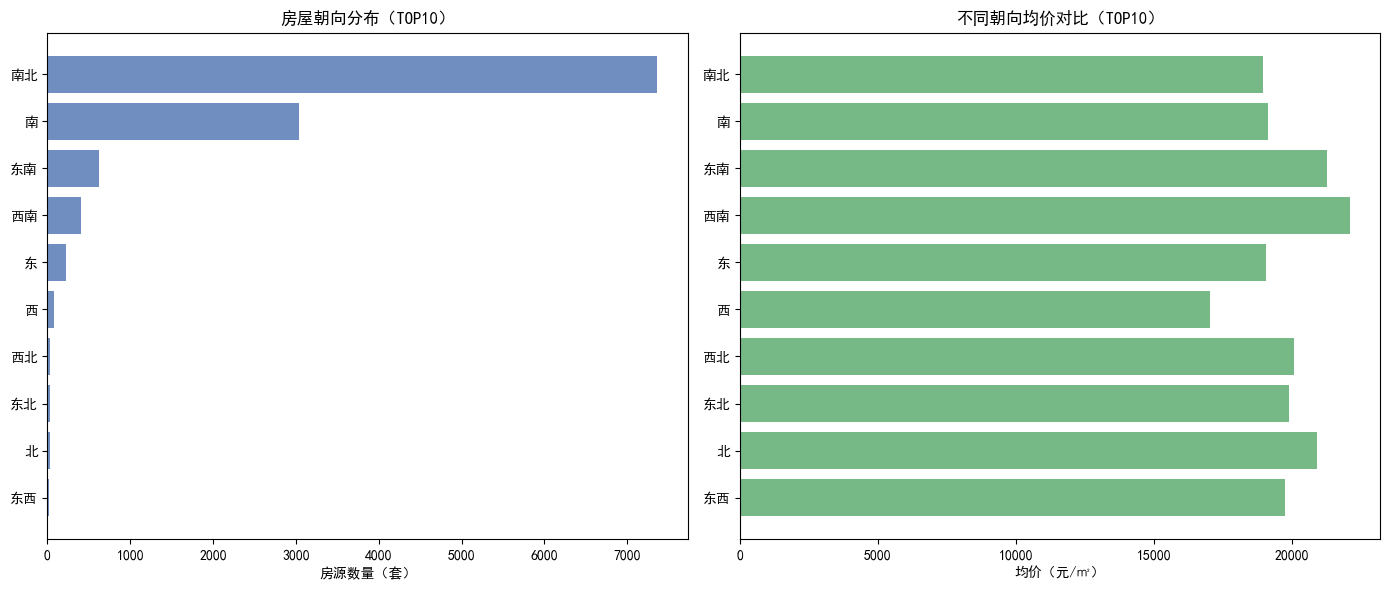

In [14]:
# 朝向分布（取TOP10）
direction_count = df['方位'].value_counts().head(10)
direction_price = df.groupby('方位')['均价数值'].mean().loc[direction_count.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].barh(direction_count.index[::-1], direction_count.values[::-1], color='#4C72B0', alpha=0.8)
axes[0].set_xlabel('房源数量（套）')
axes[0].set_title('房屋朝向分布（TOP10）')

bars2 = axes[1].barh(direction_price.index[::-1], direction_price.values[::-1], color='#55A868', alpha=0.8)
axes[1].set_xlabel('均价（元/㎡）')
axes[1].set_title('不同朝向均价对比（TOP10）')

plt.tight_layout()
plt.show()

- 南北朝向的房源数量遥遥领先，是市场绝对主流户型，其次是纯南向房源，其余朝向供给量都很低。
- 均价上西南、东南朝向溢价略高，东西向均价最低，但整体各朝向价差幅度有限。朝向对房价有一定影响，但远不如区域、面积的影响程度大。

### 4.7 区域价格箱线图

C:\Users\lenovo\AppData\Local\Temp\ipykernel_44988\3516580098.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='市区', y='均价数值', data=df_main,


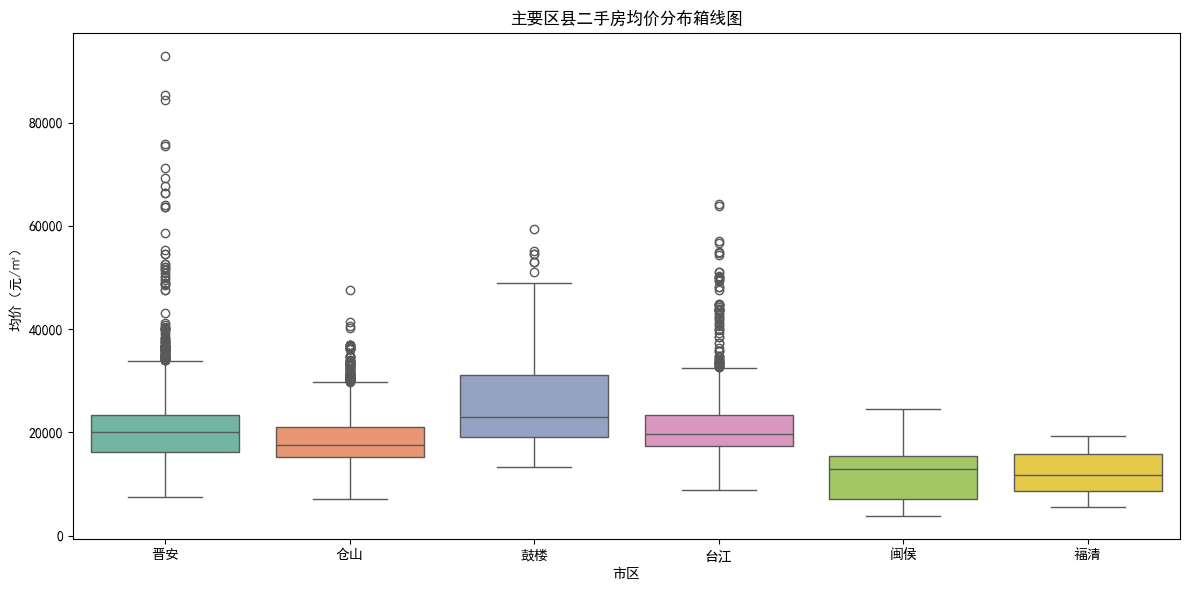

In [15]:
# 主要区域均价箱线图
main_districts = df['市区'].value_counts().head(6).index.tolist()
df_main = df[df['市区'].isin(main_districts)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='市区', y='均价数值', data=df_main, 
            order=main_districts, palette='Set2', ax=ax)
ax.set_xlabel('市区')
ax.set_ylabel('均价（元/㎡）')
ax.set_title('主要区县二手房均价分布箱线图')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- 市区四区（晋安、仓山、鼓楼、台江）房价整体水位显著高于闽侯、福清等郊县；
- 同时市区内部价差极大，存在大量高价异常点，尤其是鼓楼、台江高端房源众多，价格上限很高。
- 郊县箱体更窄，价格分布更集中，高端房源稀少，房价整体偏低且梯度平缓，市场层级差异清晰。

## 5. 结论

### 主要发现

1. **区域分化明显**：鼓楼区均价最高（约2.5万元/㎡），台江次之，晋安和仓山为房源主力供应区，合计占比约70%。

2. **价格分布**：均价中位数约1.8万元/㎡，总价集中在130-225万区间，市场以刚需和改善型房源为主。

3. **户型结构**：3室户型占比超60%，为市场绝对主流；随着室数增加，总价显著上升，但均价变化不大。

4. **房龄影响**：房龄与价格呈明显负相关，2年内新房均价最高，10年以上老房均价最低，新房溢价效应显著。

5. **面积与总价**：面积与总价呈正相关（相关系数约0.62），符合市场基本规律。

6. **楼层与朝向**：高层房源数量最多，南北朝向为绝对主流且价格相对较高。

# 二手房数据分析结论

## 一、核心发现
1. 区域分化明显：鼓楼区均价最高（约2.5万元/㎡），台江次之，晋安和仓山为房源主力供应区，合计占比约70%。

2. 价格分布：均价中位数约1.8万元/㎡，总价集中在130-225万区间，市场以刚需和改善型房源为主。

3. 户型结构：3室户型占比超60%，为市场绝对主流；随着室数增加，总价显著上升，但均价变化不大。

4. 房龄影响：房龄与价格呈明显负相关，2年内新房均价最高，10年以上老房均价最低，新房溢价效应显著。

5. 面积与总价：面积与总价呈正相关（相关系数约0.62），符合市场基本规律。

6. 楼层与朝向：高层房源数量最多，南北朝向为绝对主流且价格相对较高。


## 二、图表与统计结果支撑
1. 区域房价差异：由**各区域均价柱状图、各区域总价对比图、区域价格箱线图**共同支撑，可直接读取各区域均值、中位数的差值，箱体分布的区间差异直观可见。
2. 面积与总价相关性：由**面积-总价散点图+拟合趋势线**支撑，可计算得到正相关系数，趋势线斜率明确体现面积增长带动总价上升的规律。
3. 户型分布特征：由**户型占比柱状图/饼图、不同户型均价/总价对比图**支撑，三居室样本量占比排名第一，是市场供需两端的主力产品。
4. 房龄与价格关系：由**房龄分段占比饼图、不同房龄段均价柱状图**支撑，能直观观测到房龄递增时均价的整体下降趋势。

## 三、数据局限与谨慎解释
1. 本次数据为挂牌报价，不是实际成交价格，仅反映业主的报价预期，不能完全等同于真实市场成交价，实际交易通常存在议价空间。
2. 数据为单一时间截面的样本，无法反映房价随时间的涨跌趋势，不能用于推断未来价格走势。
3. 数据缺少学区、地铁距离、装修标准、物业品质等对房价影响较大的变量，无法排除混杂因素干扰，不能将价格差异完全归因于区域、面积等已分析字段。
4. 样本可能存在区域覆盖不均、房源类型偏斜的问题，结论仅适用于本次样本范围，不能无限制推广到全部二手房市场。